Sel 1 — Mount Google Drive & Install Library

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install tensorflow opencv-python matplotlib seaborn tqdm -q

Mounted at /content/drive


Sel 2 — Import Library

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report,
                             confusion_matrix)

Sel 3 — Konfigurasi Path & Parameter

In [ ]:
BASE_DIR   = Path("/content/drive/MyDrive/Pothole_Classification_Project")
TRAIN_DIR  = BASE_DIR / "dataset/2_processed/train"
TEST_DIR   = BASE_DIR / "dataset/2_processed/test"
MODEL_DIR  = BASE_DIR / "saved_models"
OUTPUT_DIR = BASE_DIR / "outputs"

CLASSES    = ["berlubang", "mulus"]
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 30

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Konfigurasi siap.")

✅ Konfigurasi siap.


Sel 4 — Data Generator

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    validation_split       = 0.2
)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = "binary",
    shuffle      = True,
    seed         = 42,
    subset       = "training"
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = "binary",
    shuffle      = False,
    seed         = 42,
    subset       = "validation"
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = "binary",
    shuffle      = False
)

print(f"✅ Generator siap.")
print(f"   Train      : {train_generator.samples} gambar")
print(f"   Validasi   : {val_generator.samples} gambar")
print(f"   Test       : {test_generator.samples} gambar")
print(f"   Class indices: {train_generator.class_indices}")

Found 2464 images belonging to 2 classes.
Found 616 images belonging to 2 classes.
Found 70 images belonging to 2 classes.
✅ Generator siap.
   Train      : 2464 gambar
   Validasi   : 616 gambar
   Test       : 70 gambar
   Class indices: {'berlubang': 0, 'mulus': 1}


Sel 5 — Bangun Arsitektur Model

In [ ]:
print("🔧 Membangun arsitektur MobileNetV2 + Custom Head...\n")

base_model = MobileNetV2(
    input_shape = (*IMG_SIZE, 3),
    include_top = False,
    weights     = "imagenet"
)
base_model.trainable = False

x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(128, activation="relu", kernel_regularizer=l2(1e-4))(x)
x      = Dropout(0.5)(x)
x      = Dense(64,  activation="relu", kernel_regularizer=l2(1e-4))(x)
x      = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model  = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss      = "binary_crossentropy",
    metrics   = ["accuracy"]
)

print(f"✅ Model siap. Total parameter: {model.count_params():,}")
print(f"   Trainable    : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"   Non-trainable: {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")

🔧 Membangun arsitektur MobileNetV2 + Custom Head...

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model siap. Total parameter: 2,430,273
   Trainable    : 172,289
   Non-trainable: 2,257,984


Sel 6 — Fase 1: Training Custom Head

In [ ]:
print("🏋️  Fase 1: Melatih Custom Head (base model dibekukan)...\n")

callbacks_phase1 = [
    EarlyStopping(monitor="val_accuracy", patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
]

history_phase1 = model.fit(
    train_generator,
    epochs          = 15,
    validation_data = val_generator,
    callbacks       = callbacks_phase1,
    verbose         = 1
)

print("\n✅ Fase 1 selesai.")

🏋️  Fase 1: Melatih Custom Head (base model dibekukan)...

Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 370s 5s/step - accuracy: 0.8839 - loss: 0.3015 - val_accuracy: 0.9968 - val_loss: 0.0696 - learning_rate: 0.0010
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.9590 - loss: 0.1516 - val_accuracy: 0.9984 - val_loss: 0.0453 - learning_rate: 0.0010
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9688 - loss: 0.1268 - val_accuracy: 0.9984 - val_loss: 0.0407 - learning_rate: 0.0010
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.9761 - loss: 0.1034 - val_accuracy: 0.9968 - val_loss: 0.0393 - learning_rate: 0.0010
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.9801 - loss: 0.0935 - val_accuracy: 1.0000 - val_loss: 0.0396 - learning_rate: 0.0010
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.9781 - loss: 0.0829 - val_accuracy: 0.9984 - val_loss: 0.0344 - learning_rate: 0.0010
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━

Sel 7 — Fase 2: Fine-Tuning

In [ ]:
print("🔓 Fase 2: Fine-tuning — membuka 20 layer teratas base model...\n")

base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer = Adam(learning_rate=5e-5),
    loss      = "binary_crossentropy",
    metrics   = ["accuracy"]
)

callbacks_phase2 = [
    EarlyStopping(monitor="val_accuracy", patience=7,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(str(MODEL_DIR / "mobilenet_best.keras"),
                    monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
]

history_phase2 = model.fit(
    train_generator,
    epochs          = EPOCHS,
    validation_data = val_generator,
    callbacks       = callbacks_phase2,
    verbose         = 1
)

print("\n✅ Fase 2 selesai.")

🔓 Fase 2: Fine-tuning — membuka 20 layer teratas base model...

Epoch 1/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9413 - loss: 0.2094
Epoch 1: val_accuracy improved from None to 0.97890, saving model to /content/drive/MyDrive/Pothole_Classification_Project/saved_models/mobilenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Pothole_Classification_Project/saved_models/mobilenet_best.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.9489 - loss: 0.1769 - val_accuracy: 0.9789 - val_loss: 0.0933 - learning_rate: 5.0000e-05
Epoch 2/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9771 - loss: 0.0904
Epoch 2: val_accuracy improved from 0.97890 to 0.99026, saving model to /content/drive/MyDrive/Pothole_Classification_Project/saved_models/mobilenet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Pothole_Classification_Project/saved_models/mobilenet_best.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.9789 - lo

Sel 8 — Plot Training History

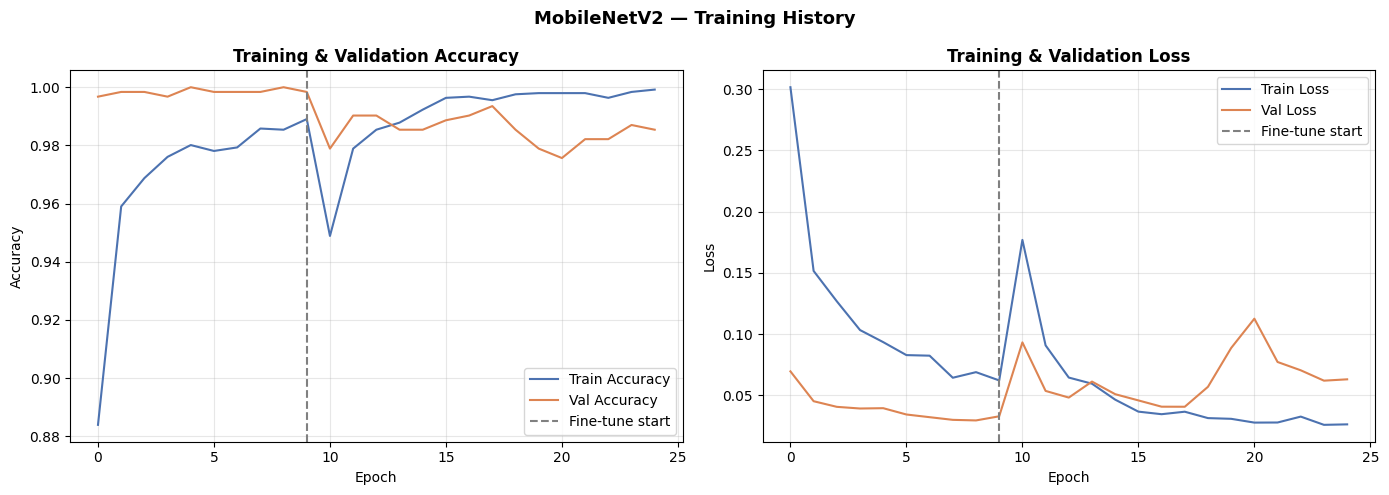

✅ Training history disimpan ke outputs/


In [ ]:
def merge_history(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

history = merge_history(history_phase1, history_phase2)
phase1_epochs = len(history_phase1.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["accuracy"],     label="Train Accuracy", color="#4C72B0")
axes[0].plot(history["val_accuracy"], label="Val Accuracy",   color="#DD8452")
axes[0].axvline(x=phase1_epochs - 1, color="gray",
                linestyle="--", label="Fine-tune start")
axes[0].set_title("Training & Validation Accuracy", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["loss"],     label="Train Loss", color="#4C72B0")
axes[1].plot(history["val_loss"], label="Val Loss",   color="#DD8452")
axes[1].axvline(x=phase1_epochs - 1, color="gray",
                linestyle="--", label="Fine-tune start")
axes[1].set_title("Training & Validation Loss", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("MobileNetV2 — Training History", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_history_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Training history disimpan ke outputs/")

Sel 9 — Evaluasi Model

In [ ]:
best_model = load_model(MODEL_DIR / "mobilenet_best.keras")

y_pred_prob = best_model.predict(test_generator, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()
y_true      = test_generator.classes

acc  = accuracy_score (y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted")
rec  = recall_score   (y_true, y_pred, average="weighted")
f1   = f1_score       (y_true, y_pred, average="weighted")

print("=" * 50)
print("     HASIL EVALUASI — MobileNetV2 (DL Murni)")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 50)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred,
      target_names=[k for k, v in sorted(
          test_generator.class_indices.items(), key=lambda x: x[1])]))

     HASIL EVALUASI — MobileNetV2 (DL Murni)
  Accuracy  : 0.9857  (98.57%)
  Precision : 0.9861
  Recall    : 0.9857
  F1-Score  : 0.9857

Classification Report:

              precision    recall  f1-score   support

   berlubang       0.97      1.00      0.99        35
       mulus       1.00      0.97      0.99        35

    accuracy                           0.99        70
   macro avg       0.99      0.99      0.99        70
weighted avg       0.99      0.99      0.99        70



Sel 10 — Confusion Matrix

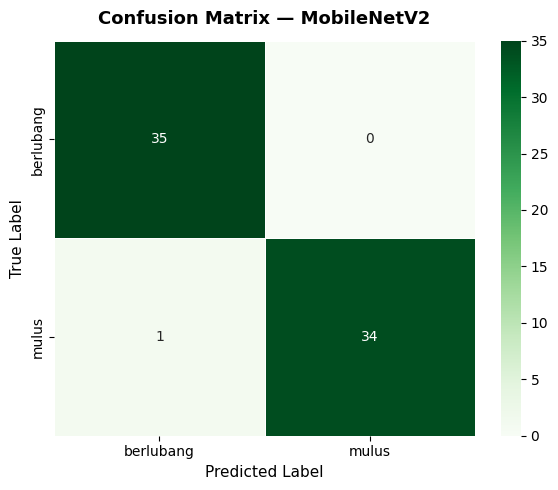

✅ Confusion matrix disimpan ke outputs/


In [ ]:
cm = confusion_matrix(y_true, y_pred)
class_names = [k for k, v in sorted(
    test_generator.class_indices.items(), key=lambda x: x[1])]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax)
ax.set_title("Confusion Matrix — MobileNetV2", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cm_mobilenet.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix disimpan ke outputs/")

Sel 11 — Grad-CAM

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="Conv_1"):
    grad_model = Model(
        inputs  = model.input,
        outputs = [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads    = tape.gradient(loss, conv_outputs)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_outputs[0]
    heatmap  = conv_out @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_path, model, size=IMG_SIZE):
    img_orig = cv2.imread(str(img_path))
    img_rgb  = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    img_disp = cv2.resize(img_rgb, size)

    img_pre  = preprocess_input(img_disp.astype(np.float32))
    img_arr  = np.expand_dims(img_pre, axis=0)

    heatmap  = make_gradcam_heatmap(img_arr, model)
    heatmap  = cv2.resize(heatmap, size)
    heatmap  = np.uint8(255 * heatmap)
    heatmap  = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap  = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    superimposed = cv2.addWeighted(img_disp, 0.6, heatmap, 0.4, 0)
    return img_disp, heatmap, superimposed

Sel 12 — Visualisasi Grad-CAM

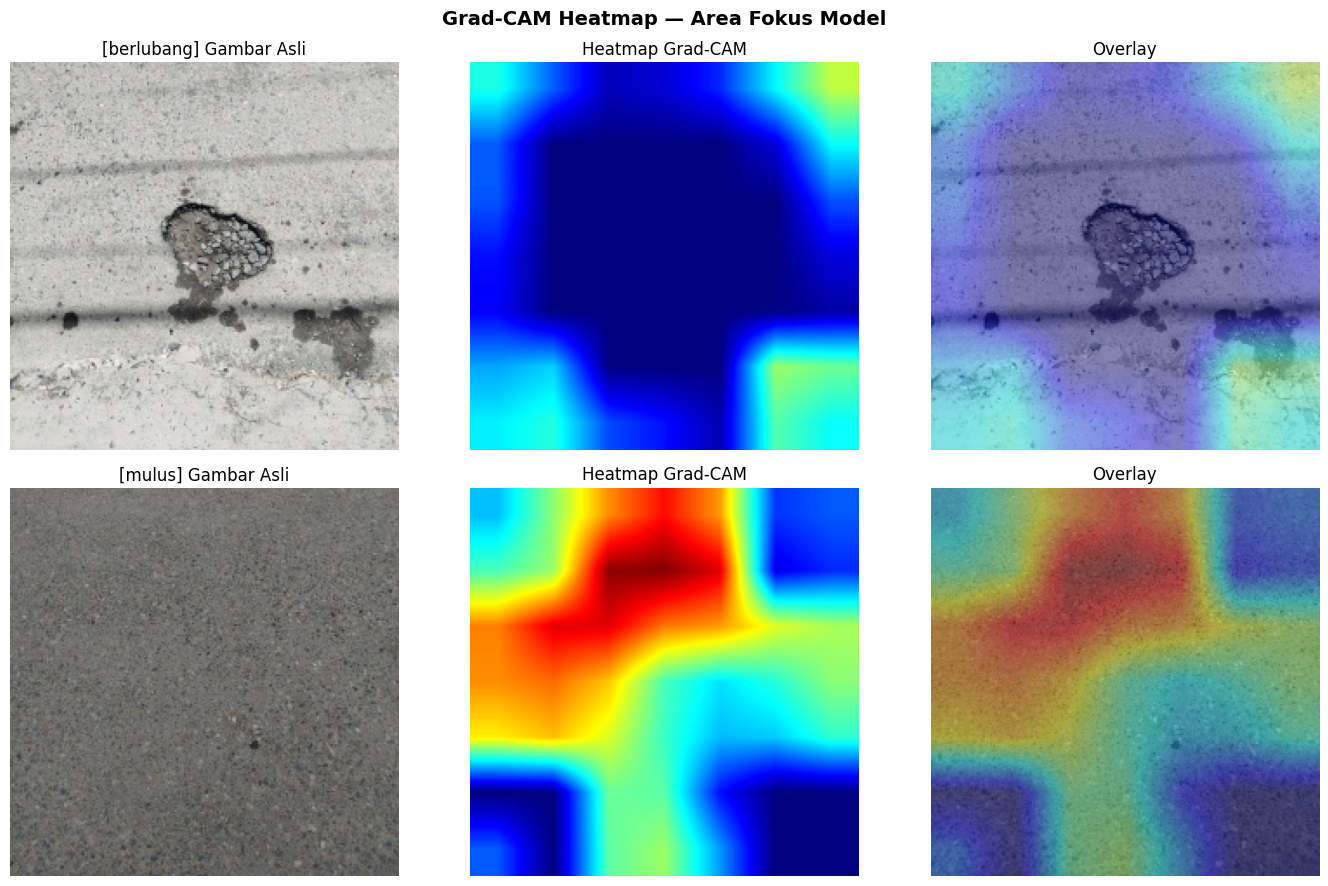

✅ Grad-CAM disimpan ke outputs/


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("Grad-CAM Heatmap — Area Fokus Model", fontsize=14, fontweight="bold")

for row, cls in enumerate(CLASSES):
    sample_path = list((TEST_DIR / cls).glob("*.jpg"))[0]
    orig, heatmap, superimposed = overlay_gradcam(sample_path, best_model)

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f"[{cls}] Gambar Asli")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(heatmap)
    axes[row, 1].set_title("Heatmap Grad-CAM")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(superimposed)
    axes[row, 2].set_title("Overlay")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "grad_cam_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grad-CAM disimpan ke outputs/")

Sel 13 — Cross Validation Score

🔍 Menghitung Cross Validation Score...



[mulus]: 100%|██████████| 1540/1540 [00:23<00:00, 65.98it/s] 


97/97 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step

  CV Scores per fold : ['0.9935', '0.9951', '0.9968', '0.9935', '0.9968']
  Mean CV Accuracy   : 0.9951 (99.51%)
  Std CV Accuracy    : 0.0015
  Test Accuracy      : 0.9857 (98.57%)
  Selisih CV vs Test : 0.0094


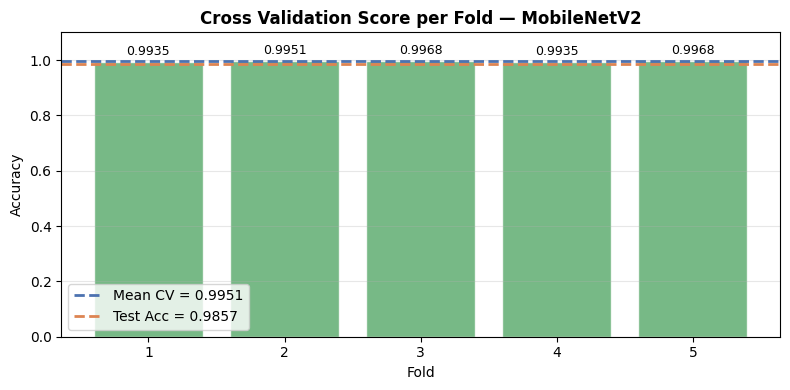

✅ CV scores disimpan ke outputs/


In [ ]:
from sklearn.model_selection import StratifiedKFold

print("🔍 Menghitung Cross Validation Score...\n")

X_cv, y_cv = [], []
for label_idx, cls in enumerate(CLASSES):
    paths = list((TRAIN_DIR / cls).glob("*.jpg"))
    for path in tqdm(paths, desc=f"[{cls}]"):
        img = cv2.imread(str(path))
        if img is None:
            continue
        img_rgb     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, IMG_SIZE)
        img_pre     = preprocess_input(img_resized.astype(np.float32))
        X_cv.append(img_pre)
        y_cv.append(label_idx)

X_cv = np.array(X_cv)
y_cv = np.array(y_cv)

feature_model = Model(
    inputs  = best_model.input,
    outputs = best_model.layers[-4].output
)
X_feat = feature_model.predict(X_cv, batch_size=32, verbose=1)

# CV dengan SVM ringan sebagai probe
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc",    SVC(kernel="rbf", C=1, random_state=42))
])

cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_feat, y_cv,
                             cv=cv, scoring="accuracy", n_jobs=-1)

print(f"\n  CV Scores per fold : {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean CV Accuracy   : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"  Std CV Accuracy    : {cv_scores.std():.4f}")
print(f"  Test Accuracy      : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Selisih CV vs Test : {abs(cv_scores.mean() - acc):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(1, 6), cv_scores, color="#55A868", alpha=0.8, edgecolor="white")
ax.axhline(cv_scores.mean(), color="#4C72B0", linestyle="--",
           linewidth=2, label=f"Mean CV = {cv_scores.mean():.4f}")
ax.axhline(acc, color="#DD8452", linestyle="--",
           linewidth=2, label=f"Test Acc = {acc:.4f}")
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_title("Cross Validation Score per Fold — MobileNetV2",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cv_scores_mobilenet.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ CV scores disimpan ke outputs/")

Sel 14 — Diagnosis Otomatis

In [ ]:
print("\n" + "=" * 50)
print("      DIAGNOSIS MODEL — MobileNetV2")
print("=" * 50)

cv_test_gap = abs(cv_scores.mean() - acc)

print(f"\n  Mean CV Accuracy   : {cv_scores.mean():.4f}")
print(f"  Test Accuracy      : {acc:.4f}")
print(f"  Std CV             : {cv_scores.std():.4f}")
print(f"  Gap CV vs Test     : {cv_test_gap:.4f}")

print("\n  📋 Kesimpulan:")

if cv_scores.mean() < 0.7 and acc < 0.7:
    print("  ⚠️  UNDERFITTING — Akurasi CV dan Test sama-sama rendah.")
    print("      Saran: tambah epoch atau buka lebih banyak layer fine-tuning.")

elif acc - cv_scores.mean() > 0.1:
    print("  ⚠️  OVERFITTING — Test accuracy jauh lebih tinggi dari CV.")
    print("      Saran: naikkan Dropout atau tambah regularisasi L2.")

elif cv_scores.mean() - acc > 0.1:
    print("  ⚠️  DISTRIBUSI TIDAK KONSISTEN — CV jauh lebih tinggi dari Test.")
    print("      Kemungkinan distribusi train dan test tidak seragam.")

elif cv_scores.std() > 0.05:
    print("  ⚠️  VARIANCE TINGGI — Performa tidak stabil antar fold.")
    print("      Model sensitif terhadap pembagian data.")

else:
    print("  ✅ MODEL SEHAT — Tidak terdeteksi overfitting maupun underfitting.")
    print(f"     Performa stabil dengan std CV = {cv_scores.std():.4f}")
    print(f"     Gap CV vs Test = {cv_test_gap:.4f} (dalam batas wajar)")

print("=" * 50)


      DIAGNOSIS MODEL — MobileNetV2

  Mean CV Accuracy   : 0.9951
  Test Accuracy      : 0.9857
  Std CV             : 0.0015
  Gap CV vs Test     : 0.0094

  📋 Kesimpulan:
  ✅ MODEL SEHAT — Tidak terdeteksi overfitting maupun underfitting.
     Performa stabil dengan std CV = 0.0015
     Gap CV vs Test = 0.0094 (dalam batas wajar)


Sel 15 — Simpan Model Final

In [ ]:
best_model.save(MODEL_DIR / "mobilenet_model.keras")

print("✅ Model final tersimpan:")
print(f"   → {MODEL_DIR / 'mobilenet_model.keras'}")

✅ Model final tersimpan:
   → /content/drive/MyDrive/Pothole_Classification_Project/saved_models/mobilenet_model.keras
